In [8]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# change the directory below to be able to read the data at your end 
df_clean = pd.read_csv(r"C:\Users\Dell\Documents\my_linux\repos_\asset_financing_risk_prediction\asset_financing\data\processed\clean.csv")

### Exploratory Data Analysis

In [10]:
# class distribution
df_clean['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

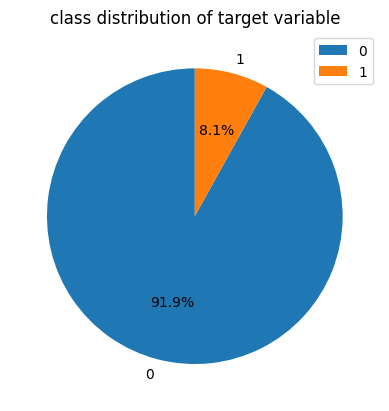

In [11]:
# 
counts = df_clean['TARGET'].value_counts()
labels = counts.index
sizes = counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("class distribution of target variable")
plt.legend()
plt.show()

#### Summarize dataset structure and key statistics.

In [12]:
# dataset summary
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307511 non-null  int64  
 1   TARGET                     307511 non-null  int64  
 2   CODE_GENDER                307511 non-null  object 
 3   FLAG_OWN_CAR               307511 non-null  object 
 4   AMT_INCOME_TOTAL           307511 non-null  float64
 5   AMT_CREDIT                 307511 non-null  float64
 6   AMT_ANNUITY                307499 non-null  float64
 7   NAME_INCOME_TYPE           307511 non-null  object 
 8   NAME_EDUCATION_TYPE        307511 non-null  object 
 9   FLAG_PHONE                 307511 non-null  bool   
 10  CNT_FAM_MEMBERS            307509 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307511 non-null  bool   
 12  AMT_REQ_CREDIT_BUREAU_MON  307511 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  30

In [13]:
# summary of categorical variables
df_clean.describe(exclude='number')

,CODE_GENDER,FLAG_OWN_CAR,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,REG_CITY_NOT_LIVE_CITY
count,307511,307511,307511,307511,307511,307511
unique,3,2,8,5,2,2
top,F,N,Working,Secondary / secondary special,False,False
freq,202448,202924,158774,218391,221080,283472


In [14]:
# summary of numerical variables
df_clean.describe(exclude='category')

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
count,307511.000000,307511.000000,307511,307511,307511.000000,3.075110e+05,307499.000000,307511,307511,307511,307509.000000,307511,307511.000000,307511.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,8,5,2,NaN,2,NaN,NaN
top,NaN,NaN,F,N,NaN,NaN,NaN,Working,Secondary / secondary special,False,NaN,False,NaN,NaN
freq,NaN,NaN,202448,202924,NaN,NaN,NaN,158774,218391,221080,NaN,283472,NaN,NaN
mean,278180.518577,0.080729,NaN,NaN,153939.251340,5.687740e+05,25899.664090,NaN,NaN,NaN,2.152665,NaN,0.231293,0.229631
std,102790.175348,0.272419,NaN,NaN,62554.665158,3.490408e+05,12080.815217,NaN,NaN,NaN,0.910682,NaN,0.856810,0.744059
min,100002.000000,0.000000,NaN,NaN,25650.000000,4.500000e+04,1615.500000,NaN,NaN,NaN,1.000000,NaN,0.000000,0.000000
25%,189145.500000,0.000000,NaN,NaN,112500.000000,2.700000e+05,16524.000000,NaN,NaN,NaN,2.000000,NaN,0.000000,0.000000
50%,278202.000000,0.000000,NaN,NaN,147150.000000,5.135310e+05,24903.000000,NaN,NaN,NaN,2.000000,NaN,0.000000,0.000000
75%,367142.500000,0.000000,NaN,NaN,189000.000000,7.819200e+05,33075.000000,NaN,NaN,NaN,3.000000,NaN,0.000000,0.000000


#### Plot correlations and key relationships.

In [15]:
# gender distribution
df_clean["CODE_GENDER"].value_counts() 

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [16]:
# drop unknown gender
df_clean = df_clean[df_clean["CODE_GENDER"] != "XNA"]

In [18]:
# gender distribution
df_clean["FLAG_OWN_CAR"].value_counts()

FLAG_OWN_CAR
N    202922
Y    104585
Name: count, dtype: int64

In [19]:
# distribution of type of income
df_clean["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158771
Commercial associate     71616
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [20]:
# merge categories with few sample into other categories
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Maternity leave","Working")
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Businessman","Commercial associate")
df_clean["NAME_INCOME_TYPE"] = df_clean["NAME_INCOME_TYPE"].replace("Unemployed","Pensioner")
# exclude student because we can't merge them into other groups and are two few to stand alone
df_clean = df_clean[df_clean["NAME_INCOME_TYPE"] != "Student"] 

In [21]:
# distribution of type of education
df_clean["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218378
Higher education                  74856
Incomplete higher                 10275
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [22]:
# merge 'academic degree' into 'higher education'
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace("Academic degree", "Higher education")
df_clean["NAME_EDUCATION_TYPE"] = df_clean["NAME_EDUCATION_TYPE"].replace("Secondary / secondary special", "secondary special")

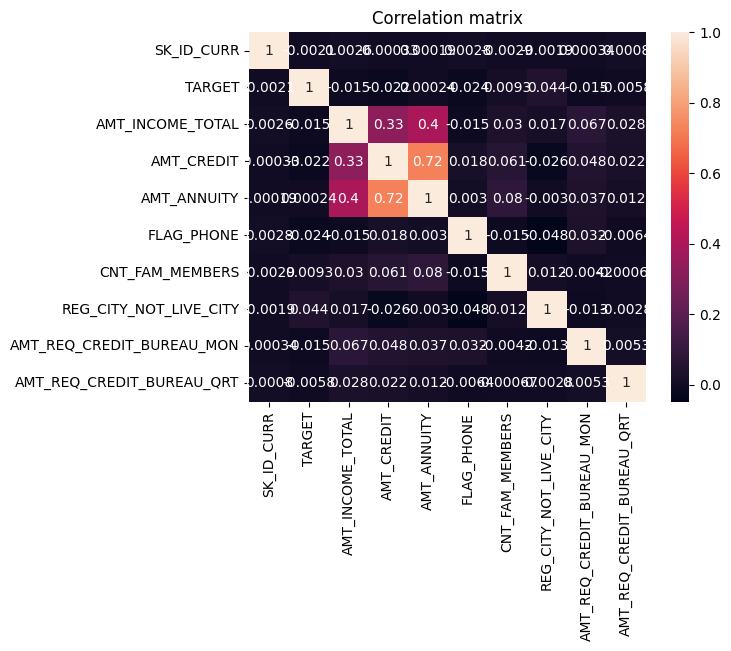

In [23]:
# compute correlation matrix
df_corr = df_clean.drop(['NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE'], axis=1)
corr_matrix = df_corr.corr()

# visualize correction matrix as a heatmap
#plt.figure(figure=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation matrix")
plt.show()

##### Level of education based analysis of annuity, credit, and total income

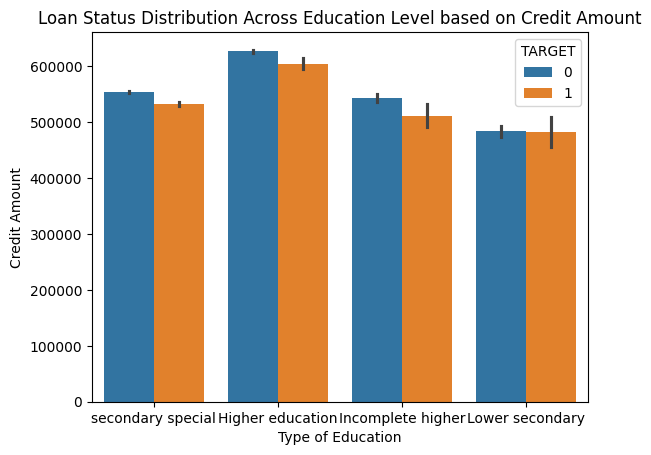

In [24]:
# 'NAME_EDUCATION_TYPE',
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Credit Amount")
plt.xlabel("Type of Education")
plt.ylabel("Credit Amount")
plt.show()

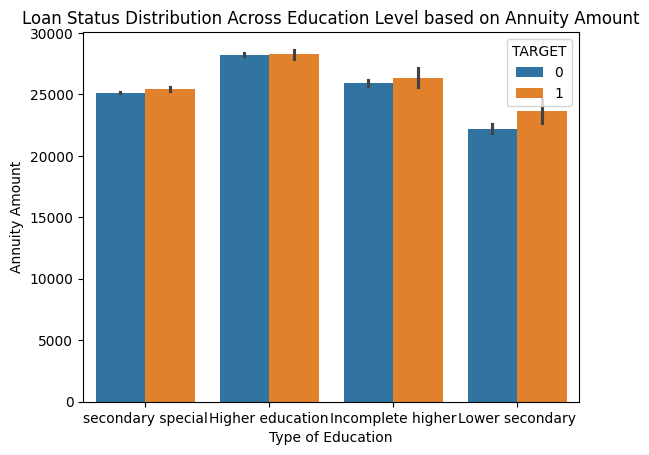

In [25]:
# 'NAME_EDUCATION_TYPE', 
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Annuity Amount")
plt.xlabel("Type of Education")
plt.ylabel("Annuity Amount")
plt.show()

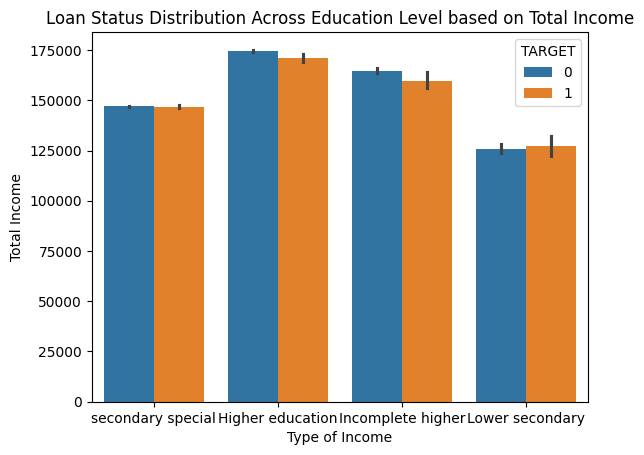

In [26]:
# 'NAME_EDUCATION_TYPE', 
sns.barplot(x="NAME_EDUCATION_TYPE", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Education Level based on Total Income")
plt.xlabel("Type of Income")
plt.ylabel("Total Income")
plt.show()

##### Gender based analysis of annuity, credit, and total income

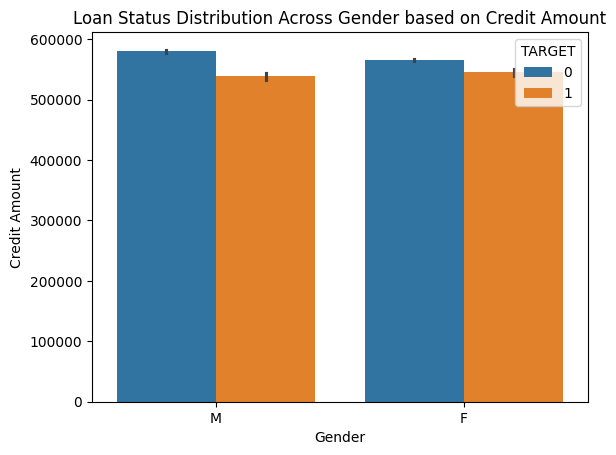

In [27]:
# 
sns.barplot(x="CODE_GENDER", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Credit Amount")
plt.xlabel("Gender")
plt.ylabel("Credit Amount")
plt.show()

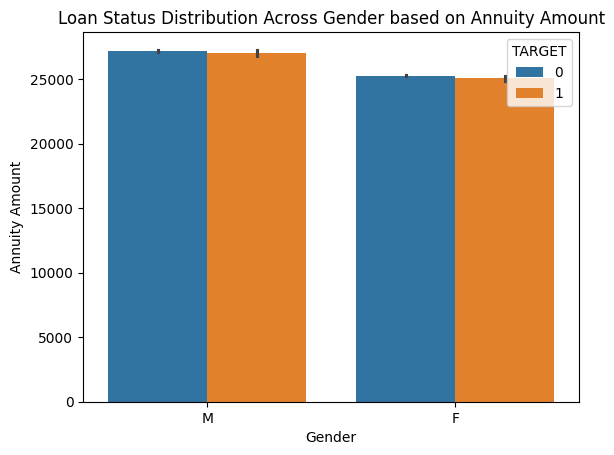

In [28]:
# 'CODE_GENDER',
sns.barplot(x="CODE_GENDER", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Annuity Amount")
plt.xlabel("Gender")
plt.ylabel("Annuity Amount")
plt.show()

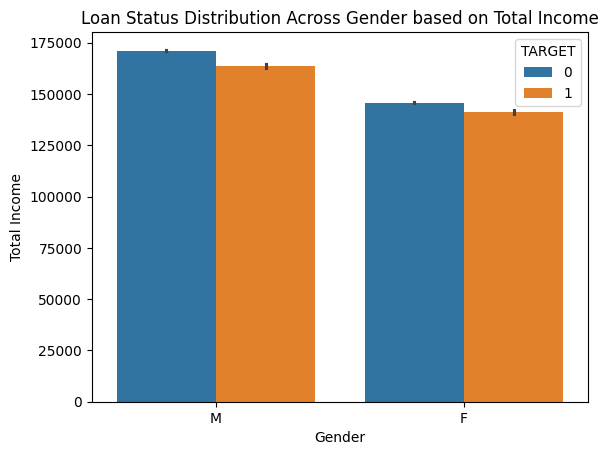

In [29]:
# 'NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE'
sns.barplot(x="CODE_GENDER", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Gender based on Total Income")
plt.xlabel("Gender")
plt.ylabel("Total Income")
plt.show()

##### Type of Income based analysis of annuity, credit, and total income

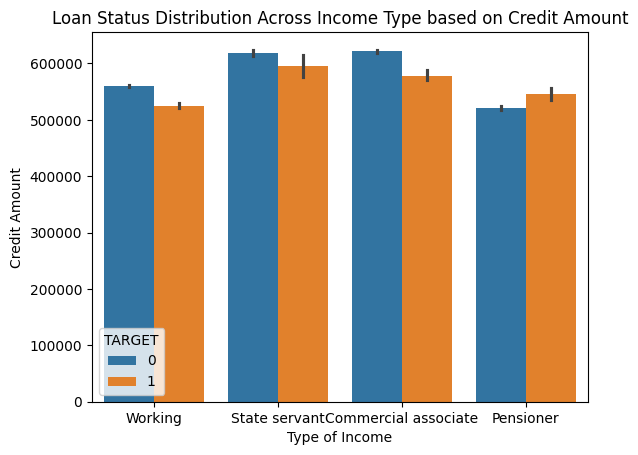

In [30]:
# 'NAME_INCOME_TYPE
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_CREDIT", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Credit Amount")
plt.xlabel("Type of Income")
plt.ylabel("Credit Amount")
plt.show()

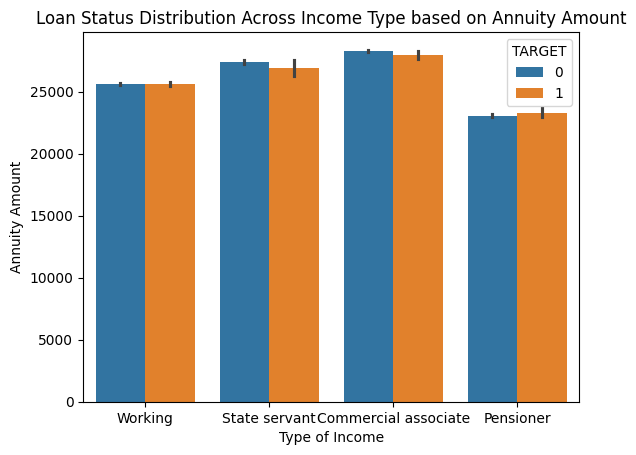

In [31]:
# 'NAME_INCOME_TYPE', 
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_ANNUITY", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Annuity Amount")
plt.xlabel("Type of Income")
plt.ylabel("Annuity Amount")
plt.show()

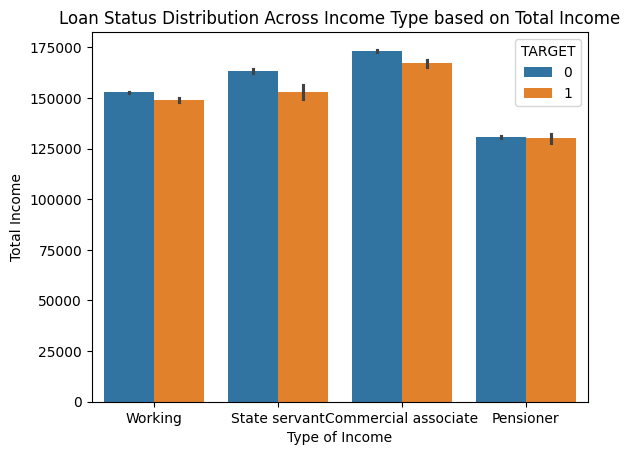

In [32]:
# 'NAME_EDUCATION_TYPE', 'FLAG_OWN_CAR', 'CODE_GENDER', 'NAME_INCOME_TYPE'
sns.barplot(x="NAME_INCOME_TYPE", y="AMT_INCOME_TOTAL", hue="TARGET", data=df_clean)
plt.title("Loan Status Distribution Across Income Type based on Total Income")
plt.xlabel("Type of Income")
plt.ylabel("Total Income")
plt.show()

### Insights from EDA
#### Descriptive Statistics
##### 1) Over 90% of the loan data entry did not default.
##### 2) The female gender took the over 66%(2/3rd) of the loans.
##### 3) Majority of those that took the loan are working class.
#### Exploratory Statistics
##### 4) With respect to gender, both the male and female had annuity of around 25000.
##### 5) The 'working class' with 'special higher education' possess the highest credit with over 600,000units irrespective of loan status.
##### 6) Clients with special higher education has income around 175,000units irrespective of loan status.
##### 7) Both the male and female gender has an estimated 550,000units in credit; with annuity of 25,000units. While the men had an estimated total income of around 160,000units; the females receive an estimated 140,000 units.
##### 8) The 'state servants' and 'commercial associates' took the most credit at 600,000units; while maintaining a steady annuity of a little over 25,000 for the same categories of workers. Compared to other workers, the 'state servants' and 'commercial associates' maintain the lead in terms of the highest total income of around 160,000units.